### Import Libraries

In [101]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

### Import CSV file

In [102]:
data = pd.read_csv('global_inflation_data.csv')
data.head(3)


,country_name,indicator_name,1980,1981,1982,1983,1984,1985,1986,1987,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Annual average inflation (consumer prices) rate,13.4,22.2,18.2,15.9,20.4,8.7,-2.1,18.4,...,-0.66,4.38,4.98,0.63,2.3,5.44,5.06,13.71,9.1,NaN
1,Albania,Annual average inflation (consumer prices) rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.90,1.30,2.00,2.00,1.4,1.60,2.00,6.70,4.8,4.0
2,Algeria,Annual average inflation (consumer prices) rate,9.7,14.6,6.6,7.8,6.3,10.4,14.0,5.9,...,4.80,6.40,5.60,4.30,2.0,2.40,7.20,9.30,9.0,6.8


### Drop rows where 2024 inflation is null

In [103]:
data = data[data['2024'].notnull()]

### Use imputer to fill missing values in earlier years

In [104]:
# Create an imputer for filling missing values
imputer = SimpleImputer(strategy='mean')

# Fill missing values in the DataFrame
data.iloc[:, 3:] = imputer.fit_transform(data.iloc[:, 3:])

### Set all columns as feature except 2024 which is target column

In [105]:
# Define features (X) and target (y)
X = data.iloc[:, 3:-1]  # All columns except 'country_name', 'indicator_name', and '2024'
y = data['2024']         # Target column

### Split 80-20

In [106]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Predict

In [107]:
# Make predictions for 2024
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 70.51


In [108]:
# Function to make predictions for each row and return the model_fit
def make_predictions(row):
    # Extract the time series data for the current row
    series = row[3:-1]  # Assuming the first three columns are not part of the time series
    
    # Convert to numeric and drop any null values
    series = pd.to_numeric(series, errors='coerce').dropna()
    
    # Check if the series is empty
    if series.empty:
        return np.nan, None  # Return NaN and None if there's no data
    
    # Fit the ARIMA model
    model = ARIMA(series, order=(1, 1, 1))  # Adjust order as necessary
    model_fit = model.fit()
    
    # Make a prediction for the next value in the series (2024)
    prediction = model_fit.forecast(steps=1)
    
    return prediction[0], model_fit  # Return both prediction and model_fit

# Apply the function to each row and store predictions and model_fit
data['2024_predicted'], model_fit = zip(*data.apply(make_predictions, axis=1))

# Save the last model_fit (or any specific one you want)
if model_fit is not None:
    model_fit[-1].save('arima_model_2024')  # Save the last model_fit

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

C:\Users\tanvi\AppData\Local\Temp\ipykernel_16816\697569905.py:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\si

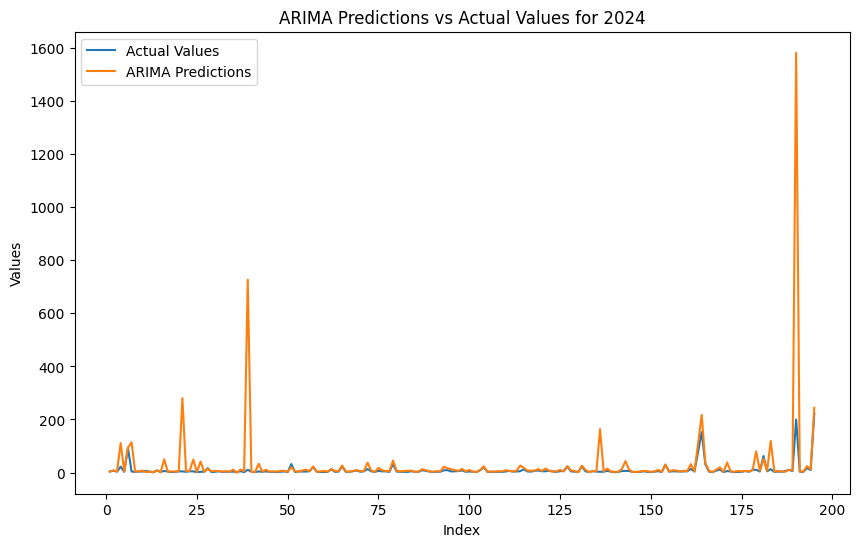

In [109]:
# Plotting ARIMA predictions vs actual values for 2024
# Assuming '2024' column exists in the data for actual values
plt.figure(figsize=(10, 6))
plt.plot(data['2024'], label='Actual Values')
plt.plot(data['2024_predicted'], label='ARIMA Predictions')
plt.title('ARIMA Predictions vs Actual Values for 2024')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.show()


In [110]:
# Selecting the first 20 countries for comparison
top_20_countries = data.head(20)

# Displaying the actual and predicted values for 2024
print(top_20_countries[['2024', '2024_predicted']])


    2024  2024_predicted
1    4.0        3.572610
2    6.8        8.058082
3    3.5        4.667868
4   22.3      111.035028
5    2.9        3.426468
6   93.7       93.181585
7    4.0      114.310914
8    2.3        3.090609
9    4.0        5.191912
10   3.7        7.238925
11   5.6        1.323218
12   3.2        3.567378
13   1.4        1.268243
14   7.9        8.200109
15   3.1        0.635573
16   5.7       49.598598
17   4.3        3.170052
18   1.7        3.995908
19   2.5        3.683344
20   4.4        5.618292


In [111]:
# Fit the model for a specific row (e.g., the first row)
series = data.iloc[0, 3:-1]  # Adjust the index as needed
series = pd.to_numeric(series, errors='coerce').dropna()

if not series.empty:
    model = ARIMA(series, order=(1, 1, 1))
    model_fit = model.fit()
    model_fit.save('arima_model_2024')  # Save the model

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

h:\Primary Workplace\Inflation-Prediction-using-ML\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

